In [1]:
import pandas as pd #판다스 패키지 불러오기
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sys

pd.set_option("display.max_columns", 100) #모든 열을 보여줌
plt.rc('font', family='Malgun Gothic')

In [2]:
data_path='C:/Users/USER/Desktop/참가 공모전/빅콘(22년 9월)/데이터셋/'
# user_df=pd.read_csv(data_path+'/user_spec.csv')
# loan_df=pd.read_csv(data_path+'/loan_result.csv')
train_loan_df = pd.read_csv(data_path+'loan_df_train.csv')
#test_loan_df = pd.read_csv(data_path+'loan_df_test.csv')
log_df = pd.read_csv(data_path+'/log_data.csv')

# 세션 부여하기 

In [91]:
import matplotlib.pyplot as plt
import seaborn as sys
cond = (~log_df['timediff'].isna()) & (log_df['timediff_cat'] =='30분 이상')
plt.rc('font', family='Malgun Gothic')

sys.countplot(y=log_df.loc[cond,'event'])
plt.xticks(rotation=90)
plt.title('차분 30분 이상인 이벤트')

image_path='C:/Users/USER/Desktop/참가 공모전/빅콘(22년 9월)/시각화/'
plt.savefig(image_path+"차분 30분 이상인 이벤트.png", format="png", dpi=300, bbox_inches="tight")

In [148]:
from datetime import timedelta
from pandas.api.types import CategoricalDtype

log_df['timestamp'] = pd.to_datetime(log_df['timestamp'])

# 동일한 timestamp일때, 이벤트 순서 지정 
event_order = [
    'SignUp','OpenApp','Login','ViewLoanApplyIntro',
'StartLoanApply','CompleteIDCertification','EndLoanApply',
'UseLoanManage','UsePrepayCalc','UseDSRCalc','GetCreditInfo']
event_type = CategoricalDtype(categories=event_order, ordered=True)

# event 컬럼을 Categorical 타입으로 변환
log_df['event'] = log_df['event'].astype(event_type)

# 로그 데이터 정렬 ( 유저 - 시간 - 이벤트 순서)
log_df = log_df.sort_values(['user_id', 'timestamp','event']).reset_index(drop=True)

In [149]:
# user_id별로 그룹화하고, 각 그룹 내에서 세션 ID 할당
def assign_session_id(group):
    session_id = 0
    session_ids = []

    # 이전 타임스탬프와 이벤트 추적
    prev_timestamp = None
    for idx, row in group.iterrows(): 
        if row['event']=='OpenApp' or (prev_timestamp and (row['timestamp'] - prev_timestamp) > timedelta(minutes=30)):
            session_id += 1  # 새로운 세션 ID 할당
        session_ids.append(session_id)
        prev_timestamp = row['timestamp']

    group['session_id'] = session_ids
    return group

In [ ]:
# user_id별로 세션 ID 할당
log_df = log_df.groupby('user_id').apply(assign_session_id)
log_df = log_df.reset_index(drop=True)

In [144]:
# 차분 구하기
log_df['timediff'] = log_df.groupby('user_id')['timestamp'].diff()
# 차분을 분단위로 변환
log_df['timediff'] = pd.to_timedelta(log_df['timediff']).dt.total_seconds() / 60

In [145]:
def change_category(x):
    if x<10:
        return '10분 미만'
    elif x>=10 and x<20:
        return '10~20분'
    elif x>=20 and x<30:
        return '20~30분'
    else:
        return '30분 이상'
    
log_df['timediff_cat'] = log_df['timediff'].apply(lambda x : change_category(x))
log_df.head()

,user_id,event,timestamp,mp_os,mp_app_version,date_cd,session_id,timediff,timediff_cat
0,1,NaN,2022-05-03 14:52:28,android,464,2022-05-03,0,NaN,30분 이상
1,1,NaN,2022-05-03 14:52:35,android,464,2022-05-03,0,0.116667,10분 미만
2,1,NaN,2022-06-16 23:58:41,Android,3.12.1,2022-06-16,1,63906.100000,30분 이상
3,1,NaN,2022-06-16 23:58:41,Android,3.12.1,2022-06-16,1,0.000000,10분 미만
4,1,NaN,2022-06-16 23:58:42,android,464,2022-06-16,1,0.016667,10분 미만


In [ ]:
col_dict = {
    'SignUp':'회원가입','OpenApp':'앱 실행','Login':'로그인'
    ,'ViewLoanApplyIntro':'한도조회 페이지 조회',
    'StartLoanApply':'한도조회 시작버튼 클릭'
    ,'CompleteIDCertification':'본인인증완료','EndLoanApply':'한도조회 결과확인',
    'UseLoanManage':'대출관리서비스 이용','UsePrepayCalc':'여윳돈계산기 이용'
    ,'UseDSRCalc':'DSR계산기 이용','GetCreditInfo':'신용정보 조회'
}

log_df['event'] = log_df['event'].apply(lambda x : col_dict[x])

In [ ]:
data_path='C:/Users/USER/Desktop/참가 공모전/빅콘(22년 9월)/데이터셋/'

log_df.to_csv(data_path+'log_df(전처리 완).csv',index=False)

# 2. 이탈률 분석
- 한도조회 시작부터 결과 조회까지를 하나의 프로세스로 정의
- 이탈률 : 1 - 프로세스 완료 / 프로세스 시작횟수 

In [2]:
data_path='C:/Users/USER/Desktop/참가 공모전/빅콘(22년 9월)/데이터셋/'
log_df = pd.read_csv(data_path+'log_df(전처리 완).csv')

## 대출 신청 단계별 소요시간 분석
1. Step1 : 한도조회 페이지 조회 -> 한도조회 시작버튼 클릭 ( 분석 x )
2. Step2 : 한도조회 시작버튼 클릭 -> 본인인증완료
3. Step3 : 본인인증완료 -> 한도조회 결과확인

In [40]:
 mapping_dict = {'GetCreditInfo':'한도조회 페이지 조회',
 'Login':'로그인',
 'UseLoanManage':'대출관리서비스 이용',
 'OpenApp':'앱 실행',
 'UsePrepayCalc':'여윳돈계산기 이용',
 'ViewLoanApplyIntro':'한도조회 페이지 조회',
 'StartLoanApply':'한도조회 시작버튼 클릭',
 'CompleteIDCertification':'본인인증완료',
 'EndLoanApply':'한도조회 결과확인',
 'SignUp':'회원가입',
 'UseDSRCalc':'DSR계산기 이용'}

log_df['event'] = log_df['event'].apply(lambda x : mapping_dict[x])

In [41]:
# user_id별로 그룹화하고, 각 그룹 내에서 세션 ID 할당
event_step_dict ={ '한도조회 시작버튼 클릭':1, '본인인증완료':2, '한도조회 결과확인':3
}

def collect_timediff_per_step(group):
    temp_dict = {1 :[], 2:[], 3:[]}
    
    # 이전 타임스탬프와 이벤트 추적
    prev_session_id = 0
    prev_event = 0
    for idx, row in group.iterrows():
        # 첫번째 행이거나 세션이 바뀔경우, 다음 row로
        if row['session_id']!=prev_session_id or idx == 0 :
            continue
        prev_session_id = row['session_id']
        
        # 1. 이벤트가 대출 신청 프로세스  and  2. 이전 프로세스의 다음 단계일 경우
        if row['event'] in list(event_step_dict.keys()) and event_step_dict[row['event']] == prev_event+1:
            temp_dict[event_step_dict[row['event']]].append(row['timediff'])
            prev_event = event_step_dict[row['event']]
        else:
            prev_event = 0
    
    
    return temp_dict

In [42]:
# 단계별 소요시간 계산
temp_dict = collect_timediff_per_step(log_df)

### 대출 Step별 소요시간 히스토그램

In [43]:
print(np.nanquantile(temp_dict[1],0.95))
print(np.nanquantile(temp_dict[2],0.95))
print(np.nanquantile(temp_dict[3],0.95))

1.0000000000000002
1.5333333333333334
6.9


                   0
count  141224.000000
mean        0.322208
std         1.721927
min         0.000000
25%         0.000000
50%         0.000000
75%         0.083333
max        30.000000


<AxesSubplot:ylabel='Count'>

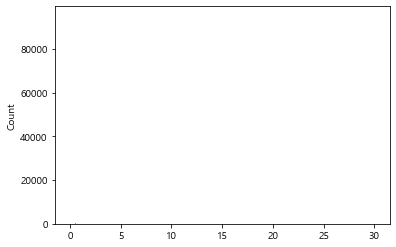

In [44]:
print(pd.DataFrame(temp_dict[1]).describe())

import matplotlib.pyplot as plt
import seaborn as sys

sys.histplot(temp_dict[1])

In [38]:
print(pd.DataFrame(temp_dict[2]).describe())

import matplotlib.pyplot as plt
import seaborn as sys

sys.histplot(temp_dict[2])

In [39]:
print(pd.DataFrame(temp_dict[3]).describe())

import matplotlib.pyplot as plt
import seaborn as sys

sys.histplot(temp_dict[3])

### 대출 Step별 소요시간 비율 - Piechart

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sys
from collections import Counter

step1_list = temp_dict[1]

def return_cat(x):
    if x < 1:
        return '1분 미만'
    elif x>=1 and x<3:
        return '1~3분'
    elif x>=3 and x<5:
        return '3~5분'
    elif x>=5 and x<10:
        return '5~10분'
    else:
        return '10분 이상'
    
temp_list1 = list(map(lambda x : return_cat(x),step1_list))

# 각 원소의 개수 세기
count = Counter(temp_list1)
print(count)

# 특정 수치 기준 설정
threshold = 5

# 기준보다 작은 카테고리를 "기타"로 묶기
labels = []
sizes = []
other_count = 0
other_labels = []  # 기타 항목의 세부 항목 리스트

sorted_data = sorted(list(count.items()), key=lambda x: x[1], reverse=True)

for item, freq in sorted_data:
    if (freq/sum(count.values()))*100< threshold:
        other_count += freq
        other_labels.append(f"{item}: {round((freq/sum(count.values()))*100,1)}%")  # 항목명과 수치를 포함한 정보 추가
    else:
        labels.append(item)
        sizes.append(freq)

# "기타" 항목 추가
if other_count > 0:
    labels.append('Other')
    sizes.append(other_count)

# 파이차트 생성
explode = [0.03] * 2


plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140,textprops={'fontsize': 13},explode=explode)
plt.axis('equal')  # 원형 파이차트를 유지
plt.title('Step1 소요시간 비율', fontsize=18)  # 제목 설정
plt.subplots_adjust(top=1.3)

# 범례에 "기타" 항목과 세부 정보 추가
base_labels = []

for label, size in zip(labels[:-1],sizes[:-1]):
    base_labels.append(f"{label}: {round((size/sum(count.values()))*100,1)}%")

other_details = '\n'.join(other_labels)  # 기타 항목 세부 정보 합치기
plt.legend([*base_labels, f"Other: \n{other_details}"], loc="upper right", bbox_to_anchor=(1, 1))


image_path='C:/Users/USER/Desktop/참가 공모전/빅콘(22년 9월)/시각화/'
#plt.savefig(image_path+"대출 Step1 소요시간 비율.png", format="png", dpi=300, bbox_inches="tight")
# 차트 표시
plt.show()

In [202]:
import matplotlib.pyplot as plt
import seaborn as sys
from collections import Counter

step2_list = temp_dict[2]

def return_cat(x):
    if x < 1:
        return '1분 미만'
    elif x>=1 and x<3:
        return '1~3분'
    elif x>=3 and x<5:
        return '3~5분'
    elif x>=5 and x<10:
        return '5~10분'
    else:
        return '10분 이상'
    
temp_list2 = list(map(lambda x : return_cat(x),step2_list))

# 각 원소의 개수 세기
count = Counter(temp_list2)
print(count)

# 특정 수치 기준 설정
threshold = 5

# 기준보다 작은 카테고리를 "기타"로 묶기
labels = []
sizes = []
other_count = 0
other_labels = []  # 기타 항목의 세부 항목 리스트

sorted_data = sorted(list(count.items()), key=lambda x: x[1], reverse=True)

for item, freq in sorted_data:
    if (freq/sum(count.values()))*100< threshold:
        other_count += freq
        other_labels.append(f"{item}: {round((freq/sum(count.values()))*100,1)}%")  # 항목명과 수치를 포함한 정보 추가
    else:
        labels.append(item)
        sizes.append(freq)

# "기타" 항목 추가
if other_count > 0:
    labels.append('Other')
    sizes.append(other_count)

# 파이차트 생성
explode = [0.03] * 3

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140,textprops={'fontsize': 13},explode=explode)
plt.axis('equal')  # 원형 파이차트를 유지
plt.title('Step2 소요시간 비율', fontsize=18)  # 제목 설정
plt.subplots_adjust(top=1.3)

# 범례에 "기타" 항목과 세부 정보 추가
base_labels = []

for label, size in zip(labels[:-1],sizes[:-1]):
    base_labels.append(f"{label}: {round((size/sum(count.values()))*100,1)}%")

other_details = '\n'.join(other_labels)  # 기타 항목 세부 정보 합치기
plt.legend([*base_labels, f"Other: \n{other_details}"], loc="upper right", bbox_to_anchor=(1, 1))

image_path='C:/Users/USER/Desktop/참가 공모전/빅콘(22년 9월)/시각화/'
#plt.savefig(image_path+"대출 Step2 소요시간 비율.png", format="png", dpi=300, bbox_inches="tight")

# 차트 표시
plt.show()

In [200]:
import matplotlib.pyplot as plt
import seaborn as sys
from collections import Counter

step3_list = temp_dict[3]

def return_cat(x):
    if x < 1:
        return '1분 미만'
    elif x>=1 and x<3:
        return '1~3분'
    elif x>=3 and x<5:
        return '3~5분'
    elif x>=5 and x<10:
        return '5~10분'
    else:
        return '10분 이상'
    
temp_list3 = list(map(lambda x : return_cat(x),step3_list))

# 각 원소의 개수 세기
count = Counter(temp_list3)
print(count)

# 특정 수치 기준 설정
threshold = 5

# 기준보다 작은 카테고리를 "기타"로 묶기
labels = []
sizes = []
other_count = 0
other_labels = []  # 기타 항목의 세부 항목 리스트

sorted_data = sorted(list(count.items()), key=lambda x: x[1], reverse=True)

for item, freq in sorted_data:
    if (freq/sum(count.values()))*100< threshold:
        other_count += freq
        other_labels.append(f"{item}: {round((freq/sum(count.values()))*100,1)}%")  # 항목명과 수치를 포함한 정보 추가
    else:
        labels.append(item)
        sizes.append(freq)

# "기타" 항목 추가
if other_count > 0:
    labels.append('Other')
    sizes.append(other_count)

# 파이차트 생성
explode = [0.03] * 4

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140,textprops={'fontsize': 13},explode=explode)
plt.axis('equal')  # 원형 파이차트를 유지
plt.title('Step3 소요시간 비율', fontsize=18)  # 제목 설정
plt.subplots_adjust(top=1.3)

# 범례에 "기타" 항목과 세부 정보 추가
base_labels = []

for label, size in zip(labels[:-1],sizes[:-1]):
    base_labels.append(f"{label}: {round((size/sum(count.values()))*100,1)}%")

other_details = '\n'.join(other_labels)  # 기타 항목 세부 정보 합치기
plt.legend([*base_labels, f"Other: \n{other_details}"], loc="upper right", bbox_to_anchor=(1, 1))

image_path='C:/Users/USER/Desktop/참가 공모전/빅콘(22년 9월)/시각화/'
#plt.savefig(image_path+"대출 Step3 소요시간 비율.png", format="png", dpi=300, bbox_inches="tight")

# 차트 표시
plt.show()

In [29]:
log_df.iloc[1100:1150,:]

## 이탈률 산정 (유저 성향)
1. Step1 : 한도조회 페이지 조회 -> 한도조회 시작버튼 클릭
2. Step2 : 한도조회 시작버튼 클릭 -> 본인인증완료
3. Step3 : 본인인증완료 -> 한도조회 결과확인

- 모집단 소요시간 백분위 95%이하인 관측치 => 정상
- Step1 1분이내 정상
- Step2 1.5분 이내 정상
- Step3 10분 이내 정상

1. 기존의 조회한 결과 조회
=> 한도조회 시작버튼 클릭 + 한도조회 결과확인

2. 새로 대출 상품 조회
=> Step1 + Step2 + Step3

In [46]:
# 1. 필요없는 이벤트 삭제
dropout_df = log_df.loc[~log_df['event'].isin(['회원가입','로그인','앱 실행']),:]
print(list(dropout_df['event'].unique()))

['한도조회 페이지 조회', '대출관리서비스 이용', '여윳돈계산기 이용', '한도조회 시작버튼 클릭', '본인인증완료', '한도조회 결과확인', 'DSR계산기 이용']


In [47]:
# 2. 동일 세션에서 같은 event가 1분 이내 연속 발생할 경우, 중복 삭제
# 1분 이내인 이유 : 본인인증까지 소요시간의 백분위 95% => 약 1분

dropout_df['is_duplicate'] = dropout_df.groupby(['user_id', 'session_id'])['event'].shift() == dropout_df['event']
dropout_df = dropout_df[~((dropout_df['timediff']<1)&(dropout_df['is_duplicate']))].drop(columns=['is_duplicate'])
dropout_df.head(10)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_17496\3496693569.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dropout_df['is_duplicate'] = dropout_df.groupby(['user_id', 'session_id'])['event'].shift() == dropout_df['event']


,user_id,event,timestamp,mp_os,mp_app_version,date_cd,session_id,timediff,timediff_cat
0,1,한도조회 페이지 조회,2022-05-03 14:52:28,android,464,2022-05-03,0,NaN,30분 이상
3,1,대출관리서비스 이용,2022-06-16 23:58:41,Android,3.12.1,2022-06-16,1,0.000000,10분 미만
4,1,한도조회 페이지 조회,2022-06-16 23:58:42,android,464,2022-06-16,1,0.016667,10분 미만
5,7,한도조회 페이지 조회,2022-05-22 16:39:49,android,465,2022-05-22,0,NaN,30분 이상
6,9,한도조회 페이지 조회,2022-05-21 23:37:58,android,465,2022-05-21,0,NaN,30분 이상
7,9,한도조회 페이지 조회,2022-05-21 23:43:33,android,465,2022-05-21,0,5.583333,10분 미만
10,11,한도조회 페이지 조회,2022-03-24 10:54:07,iOS,3.6.1,2022-03-24,1,0.133333,10분 미만
11,11,대출관리서비스 이용,2022-03-24 10:54:08,iOS,3.6.1,2022-03-24,1,0.016667,10분 미만
12,11,한도조회 페이지 조회,2022-03-24 10:54:19,iOS,3.6.1,2022-03-24,1,0.183333,10분 미만
13,11,여윳돈계산기 이용,2022-03-24 10:54:36,iOS,3.6.1,2022-03-24,1,0.283333,10분 미만


In [48]:
# 로그 이벤트 인코딩
event_map ={'한도조회 페이지 조회':0,'한도조회 시작버튼 클릭':1,'본인인증완료':2,'한도조회 결과확인':3,
            '신용정보 조회':4,'대출관리서비스 이용':5
             ,'여윳돈계산기 이용':6,'DSR계산기 이용':7}

dropout_df['num_event'] = dropout_df['event'].apply(lambda x :event_map[x])

In [49]:
# 대출 프로세스에서 1,0 순서가 바뀐경우 삭제 ( 0을 삭제함 )
dropout_df['diff_event']= dropout_df.groupby(['user_id', 'session_id'])['num_event'].shift()
dropout_df = dropout_df.loc[~((dropout_df['num_event']==0) & (dropout_df['diff_event']==1)&(dropout_df['timediff']<0.05))]
dropout_df = dropout_df.drop(columns='diff_event')

,user_id,event,timestamp,mp_os,mp_app_version,date_cd,session_id,timediff,timediff_cat,num_event
0,1,한도조회 페이지 조회,2022-05-03 14:52:28,android,464,2022-05-03,0,NaN,30분 이상,0
3,1,대출관리서비스 이용,2022-06-16 23:58:41,Android,3.12.1,2022-06-16,1,0.000000,10분 미만,5
4,1,한도조회 페이지 조회,2022-06-16 23:58:42,android,464,2022-06-16,1,0.016667,10분 미만,0
5,7,한도조회 페이지 조회,2022-05-22 16:39:49,android,465,2022-05-22,0,NaN,30분 이상,0
6,9,한도조회 페이지 조회,2022-05-21 23:37:58,android,465,2022-05-21,0,NaN,30분 이상,0


In [76]:
# 대출 한도조회 횟수 count
def count_loan_process(event_list):
    count = 0
    if len(event_list) <2:
        return count
    for i in range(0,len(event_list) - 1):   
        if event_list[i:i+2] == [2,3]:  # 대출 한도조회 횟수 count
            count += 1
    return count

# 이벤트별 행동 count
def count_events(event_list):
    result_count = event_list.count(3)
    credit_count = event_list.count(4)
    mange_count = event_list.count(5)
    seed_count = event_list.count(6)
    dsr_count = event_list.count(7)
    
    return [result_count,credit_count,mange_count,seed_count,dsr_count]

# 이탈 유형별 횟수 count
def count_breakaway(event_list):
    break1, break2 = 0, 0
    process_on = 0
    pre_event = None

    for event in event_list:
        # 프로세스 진행중이면
        if process_on:
            if pre_event+1 == event: #  일반적인 프로세스
                if event == 3:             # 3까지 완료될때, 초기화
                    process_on = 0
                else:
                    pre_event = event 
            elif pre_event==0 and event == 2:  # 정상 프로세스이지만 1이 결측일 때 (0-2-3)
                pre_event = event
            elif pre_event==1 and event == 3:  # 기존 대출 조회 확인 ( 1-3)
                process_on = 0                 # 초기화 해줌
            else:
                if pre_event==1:    # 이탈 유형 1번 발생
                    break1+=1
                    process_on = 0
                elif pre_event ==2: # 이탈 유형 2번 발생
                    break2+=1
                    process_on = 0
                else:
                    process_on = 0
        else:
            if event <=1 :   # 한도조회 시작
                pre_event = event
                process_on = 1

    # 진행중에 세션이 끝난 경우
    if process_on ==1:
        if pre_event==1:    # 이탈 유형 1번 발생
            break1+=1
        elif pre_event>1: # 이탈 유형 2번 발생
            break2+=1
    
    return [break1, break2]
    
# 유저 행동 데이터프레임 생성 
def make_user_activity(df,columns):
    data_list = []
    user_steps = df.groupby('user_id')
    
    for user_id, user_df in user_steps:
        session_steps = user_df.groupby('session_id')
        for session_id , session_df in session_steps:  
            event_list = list(session_df['num_event'])
            #print(event_list)
            # 대출 한도조회 횟수
            loan_count = count_loan_process(event_list)
            # 이벤트별 행동 횟수
            event_count = count_events(event_list)
            # 이탈 유형별 횟수
            breakaway_list = count_breakaway(event_list)
            
            # 데이터 리스트 병합
            session_data = [loan_count]+event_count+breakaway_list
            data_list.append([user_id,session_id]+session_data)
    # 데이터프레임으로 변환
    temp_df = pd.DataFrame(data_list,columns=columns)
    
    return temp_df

In [ ]:
# 세션별 활동기록 수집 코드

# 인덱스 => user_id, session_id
# Column 1. 대출 한도 조회 완료  ( 1 - 2- 3)
# Column 2. 한도조회 결과 확인  (3)
# Column 3. 신용정보 조회
# Column 4. 대출관리서비스
# Column 5. 여윳돈 계산기
# Column 6. DSR 계산기
# Column 7.이탈률 1  ( 1-2 사이에서 이탈)
# Column 8.이탈률 2  ( 2-3 사이에서 이탈)

In [77]:
name_list = ['user_id','session_id','대출 한도조회 횟수(수)','대출한도 전체 조회(수)'
                 ,'신용조회(수)','대출관리서비스(수)','여윳돈 계산기(수)','DSR 계산기(수)'
                ,'이탈 유형1(수)','이탈 유형2(수)']
user_activity_df = make_user_activity(dropout_df,name_list)

In [65]:
#data_path='C:/Users/USER/Desktop/참가 공모전/빅콘(22년 9월)/데이터셋/'
#user_activity_df.to_csv(data_path+'user_activity_df2.csv',index=False)